In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer, make_column_selector
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import RandomUnderSampler, InstanceHardnessThreshold
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, RFE
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# !pip install xgboost
from xgboost import XGBClassifier

<h2>Exploratory Data Analysis</h2>
<li>Import & Explore the dataset

In [3]:
base = pd.read_csv("Base.csv")
base

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0,0.8,0.124690,-1,143,30,0.051348,-0.826239,AB,530,...,0,1500.0,0,INTERNET,16.967770,other,0,1,0,7
999996,0,0.9,0.824544,-1,193,30,0.009591,0.008307,AC,408,...,1,1000.0,0,INTERNET,1.504109,macintosh,0,1,0,7
999997,0,0.8,0.140891,-1,202,10,0.059287,50.609995,AA,749,...,0,200.0,0,INTERNET,16.068595,other,0,1,0,7
999998,0,0.9,0.002480,52,3,30,0.023357,-1.313387,AB,707,...,0,200.0,0,INTERNET,1.378683,linux,1,1,0,7


In [5]:
base.describe(include='all')

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000,1000000.000000,1000000,1000000.000000,1000000.000000,1000000.0,1000000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,...,NaN,NaN,NaN,2,NaN,5,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AB,NaN,...,NaN,NaN,NaN,INTERNET,NaN,other,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,370554,NaN,...,NaN,NaN,NaN,992952,NaN,342728,NaN,NaN,NaN,NaN
mean,0.011029,0.562696,0.493694,16.718568,86.587867,33.689080,1.025705e+00,8.661499,NaN,1572.692049,...,0.222988,515.851010,0.025242,NaN,7.544940,NaN,0.576947,1.018312,0.0,3.288674
std,0.104438,0.290343,0.289125,44.046230,88.406599,12.025799,5.381835e+00,20.236155,NaN,1005.374565,...,0.416251,487.559902,0.156859,NaN,8.033106,NaN,0.494044,0.180761,0.0,2.209994
min,0.000000,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,NaN,1.000000,...,0.000000,190.000000,0.000000,NaN,-1.000000,NaN,0.000000,-1.000000,0.0,0.000000
25%,0.000000,0.300000,0.225216,-1.000000,19.000000,20.000000,7.193246e-03,-1.181488,NaN,894.000000,...,0.000000,200.000000,0.000000,NaN,3.103053,NaN,0.000000,1.000000,0.0,1.000000
50%,0.000000,0.600000,0.492153,-1.000000,52.000000,30.000000,1.517574e-02,-0.830507,NaN,1263.000000,...,0.000000,200.000000,0.000000,NaN,5.114321,NaN,1.000000,1.000000,0.0,3.000000
75%,0.000000,0.800000,0.755567,12.000000,130.000000,40.000000,2.633069e-02,4.984176,NaN,1944.000000,...,0.000000,500.000000,0.000000,NaN,8.866131,NaN,1.000000,1.000000,0.0,5.000000


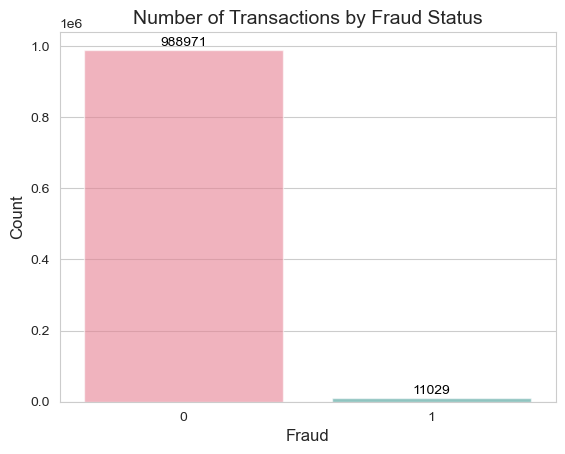

In [40]:
# Check Fraud Status

# Color & Style
my_palette = sns.color_palette("husl", 2)
sns.set_style("whitegrid")

# Plot the fraud_bool distribution
ax = sns.countplot(data=base, x="fraud_bool", hue="fraud_bool", palette=my_palette, alpha=0.6, legend=False)

# Customize labels and legend
plt.xlabel("Fraud", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title("Number of Transactions by Fraud Status", fontsize=14)

# Add numeric labels on top of bars
for p in ax.patches:
    height = int(p.get_height())  # Convert to integer
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

# Display plot
plt.show()

<li> Check Missing Values

In [7]:
# Replace missing values（-1 or negative values）with NaN

df=base.copy()

# Only select the six numerical columns with missing values
missing_cols = ['prev_address_months_count', 'current_address_months_count', 'intended_balcon_amount', 'session_length_in_minutes', 'bank_months_count', 'device_distinct_emails_8w']

# replace -1 or negative values with NaN
df[missing_cols] = df[missing_cols].replace(-1, np.nan)
for col in missing_cols:
    df[col] = df[col].map(lambda x: np.nan if x < 0 else x)

# Count missing values
df.isnull().sum()

fraud_bool                               0
income                                   0
name_email_similarity                    0
prev_address_months_count           712920
current_address_months_count          4254
customer_age                             0
days_since_request                       0
intended_balcon_amount              742523
payment_type                             0
zip_count_4w                             0
velocity_6h                              0
velocity_24h                             0
velocity_4w                              0
bank_branch_count_8w                     0
date_of_birth_distinct_emails_4w         0
employment_status                        0
credit_risk_score                        0
email_is_free                            0
housing_status                           0
phone_home_valid                         0
phone_mobile_valid                       0
bank_months_count                   253635
has_other_cards                          0
proposed_cr

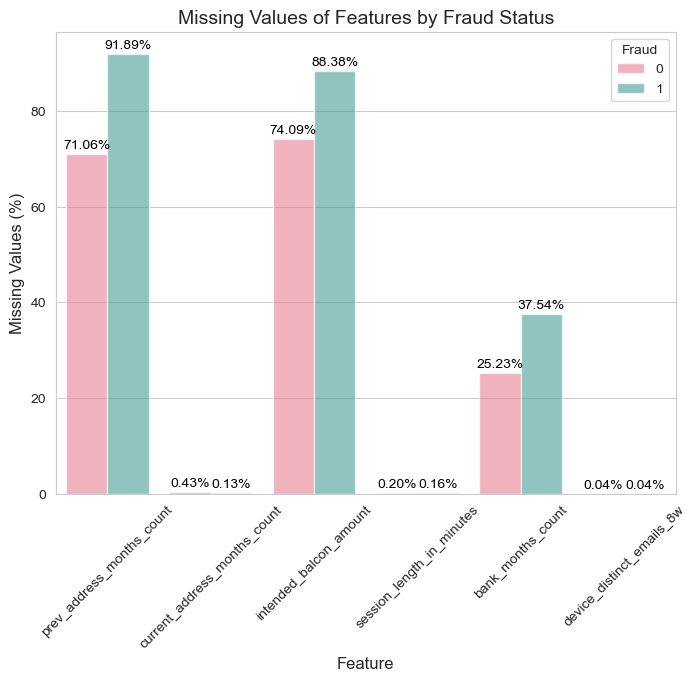

In [42]:
# Compare the percentage of missing values for features in missing_cols between fraud and non-fraud group

missing_vals = pd.DataFrame()

# Loop through features to compute missing percentage
for feature in missing_cols:
    missing_vals_col = df.groupby('fraud_bool')[feature].apply(lambda x: round(x.isna().sum() / len(x) * 100, 2))
    missing_vals[feature] = missing_vals_col

# Reformat the data for plotting
missing_vals = pd.DataFrame(missing_vals.T.stack()).reset_index()
missing_vals.columns = ['feature', 'fraud_bool', 'missing_vals']

missing_vals['fraud_bool'] = missing_vals['fraud_bool'].astype(str)

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=missing_vals, x="feature", y="missing_vals", hue="fraud_bool", palette=my_palette, alpha=.6)

# Add numeric labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue  # Skip drawing text for 0% bars
    ax.text(
        p.get_x() + p.get_width() / 2., height + 0.5,
        f'{height:.2f}%', ha='center', va='bottom', fontsize=10, color='black'
    )

ax.set_xlabel("Feature", fontsize=12)
ax.set_ylabel("Missing Values (%)", fontsize=12)
ax.tick_params(axis='x', labelrotation=45, labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.set_title("Missing Values of Features by Fraud Status", fontsize=14)
ax.legend(title="Fraud", fontsize=10)

plt.show()

<li> Deal with Missing Values

In [44]:
# too many missing values in column "prev_address_months_count" and column "intended_balcon_amount" 
# so drop this two columns
df.drop(columns=['prev_address_months_count', 'intended_balcon_amount'], inplace=True)

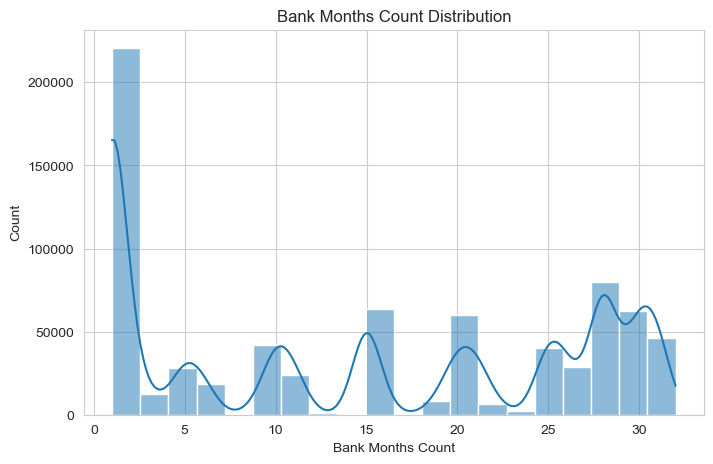

In [46]:
# 25.23% of the values are missing in column "bank_months_count"
# Check the distribuion of the values in this column

my_palette = sns.color_palette("husl", 2)

plt.figure(figsize=(8, 5))
sns.histplot(df['bank_months_count'], bins=20, kde=True)
plt.title('Bank Months Count Distribution')
plt.xlabel('Bank Months Count')
plt.ylabel('Count')
plt.show()

In [9]:
# Then, replace the missing values in the column "bank_months_count" with the most use of this column (=1)
df['bank_months_count'] = df['bank_months_count'].fillna(1)

In [11]:
# Drop the rest rows with missing values
# Check missing values again
df.dropna(inplace=True)
df.isnull().sum()

fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
employment_status                   0
credit_risk_score                   0
email_is_free                       0
housing_status                      0
phone_home_valid                    0
phone_mobile_valid                  0
bank_months_count                   0
has_other_cards                     0
proposed_credit_limit               0
foreign_request                     0
source                              0
session_leng

<li> Check Features (Binary, Numerical, Categorical)

In [13]:
# Categorize binary, numerical, categorical features

# Binary features
binary_features_name = [
    'email_is_free',
    'phone_home_valid',
    'phone_mobile_valid',
    'has_other_cards',
    'foreign_request',
    'keep_alive_session',
    'fraud_bool'
]
binary_features = df[binary_features_name]

# Numerical features
numeric_features_name=[x for x in df.columns if df[x].nunique() >= 10]
numeric_features = df[numeric_features_name]

# Categotical features
cate_features_name = df.select_dtypes(include=['object']).columns.tolist()
cate_features = df[cate_features_name]

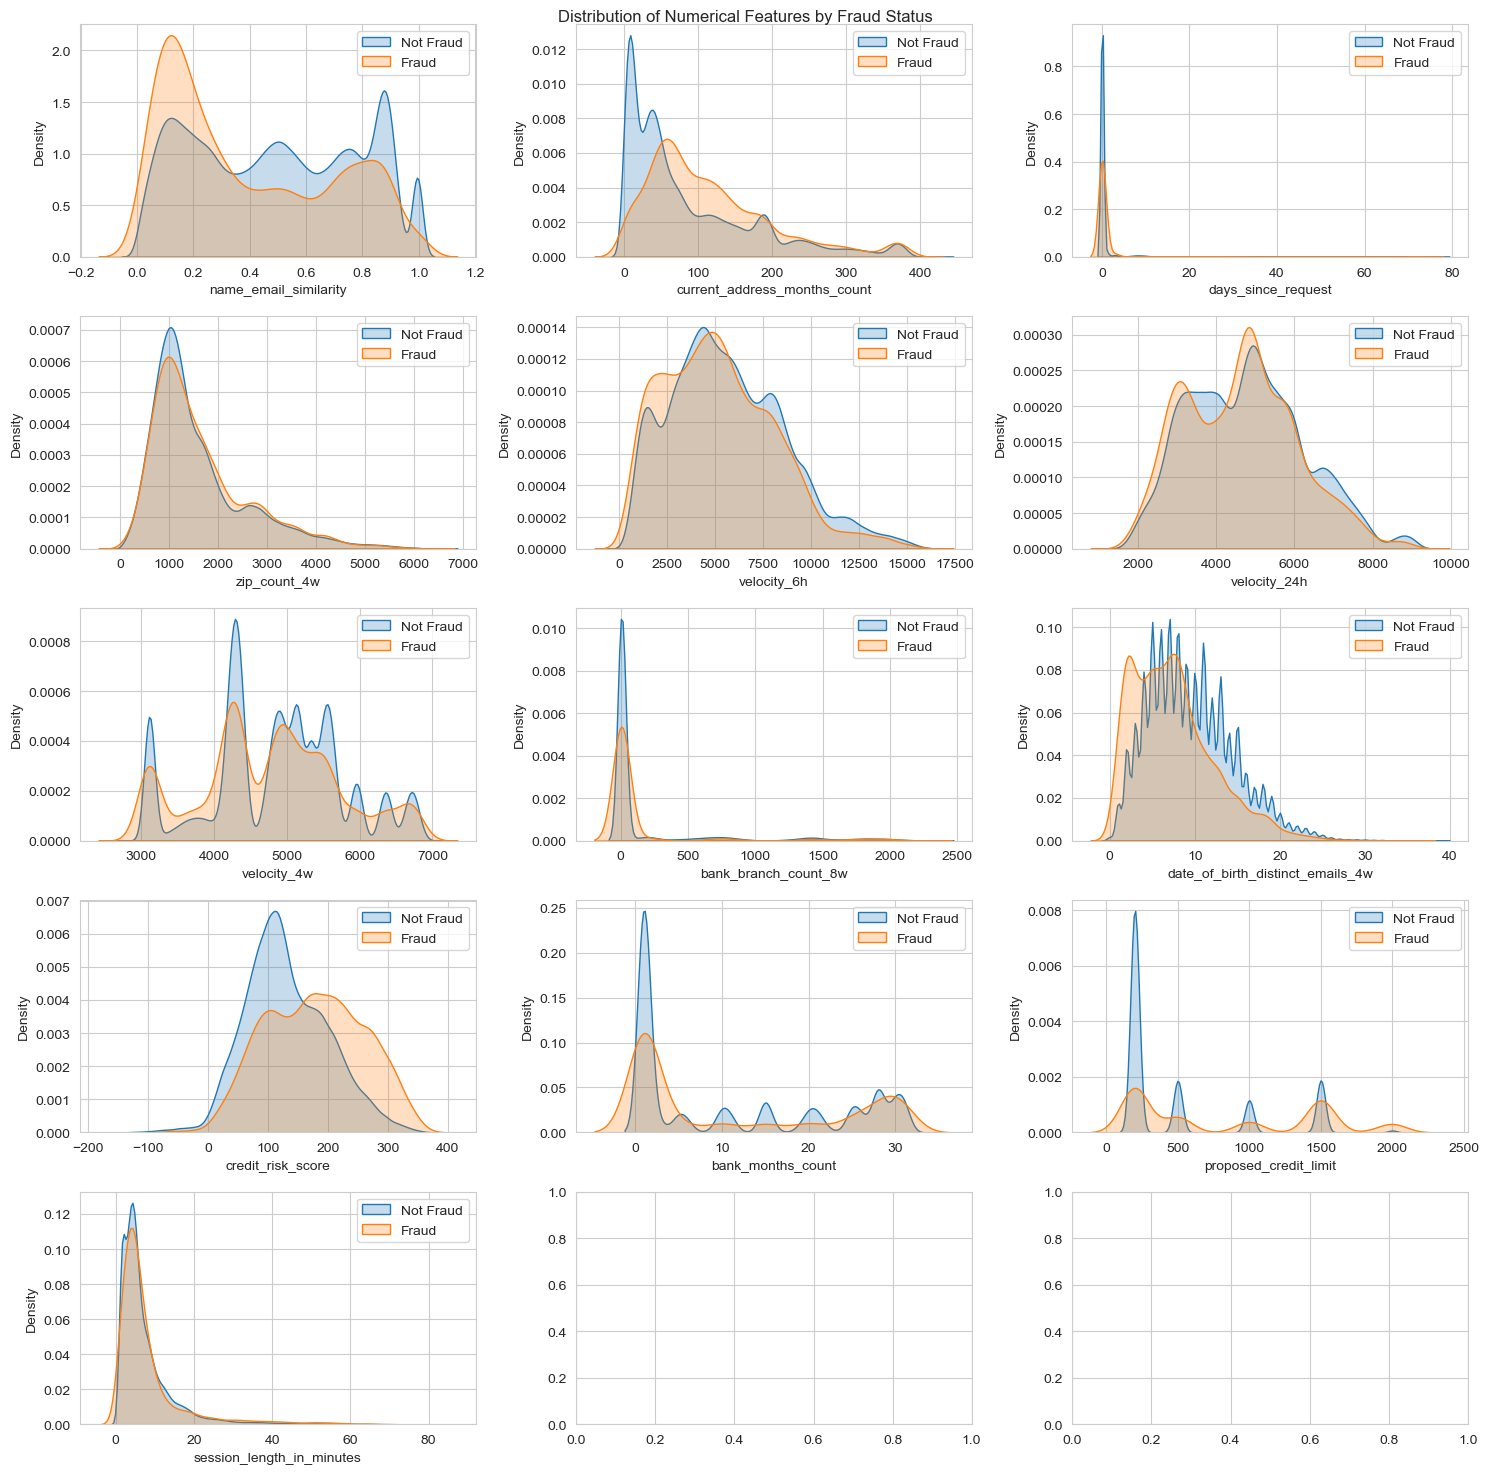

In [62]:
# Check numerical features distributions

numeric_features_name=[x for x in df.columns if df[x].nunique() >= 10][:13]

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 15))

# Add title to the figure
fig.suptitle('Distribution of Numerical Features by Fraud Status')

# Loop through the numeric features and plot a kernel density plot for each feature
for i, feature in enumerate(numeric_features_name):
    ax = axes[i // 3][i % 3]
    sns.kdeplot(data=df[df['fraud_bool'] == 0][feature], fill=True, ax=ax, label='Not Fraud')
    sns.kdeplot(data=df[df['fraud_bool'] == 1][feature], fill=True, ax=ax, label='Fraud')
    ax.set_xlabel(feature)
    ax.legend()

# Delete the last 2 unused axes
for j in range(len(numeric_features_name), len(axes)):
    fig.delaxes(axes[j]) 

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

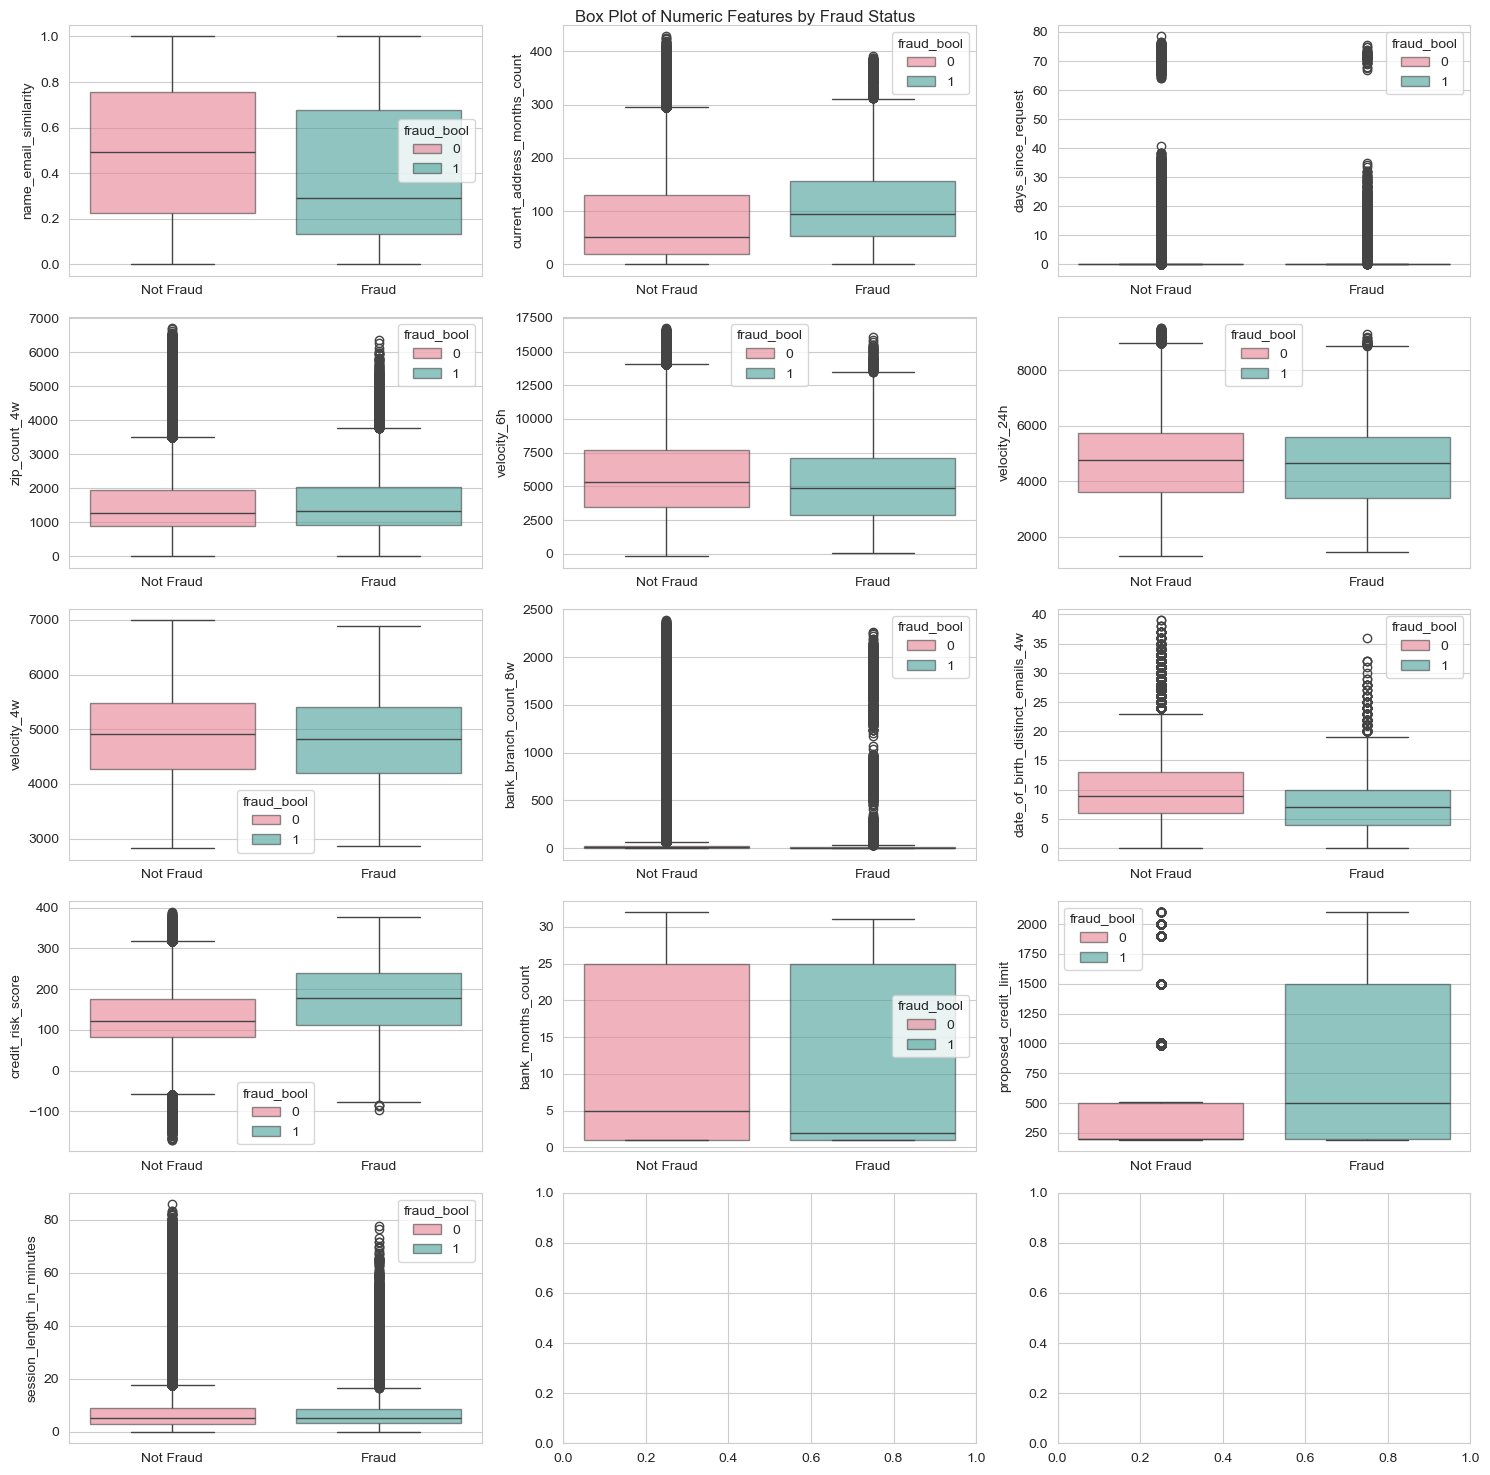

In [64]:
# Check numerical features outliers
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 15))

# Add a title to the figure
fig.suptitle('Box Plot of Numeric Features by Fraud Status')

# Loop through the numeric features and plot a box plot for each feature
for i, feature in enumerate(numeric_features_name):
    ax = axes[i // 3][i % 3]
    sns.boxplot(data=df, x='fraud_bool', y=feature, hue='fraud_bool', ax=ax, palette=my_palette, boxprops=dict(alpha=.6))
    ax.set_xlabel('')
    ax.set_ylabel(feature)
    ax.tick_params(axis='x', labelsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Not Fraud', 'Fraud'])

plt.tight_layout()  # Adjust the layout and display the plot
plt.show()

In [ ]:
'''
From the output above:
Strong signal features: name_email_similarity, date_of_birth_distinct_emails_4w, credit_risk_score, proposed_credit_limit, session_length_in_minutes
Moderate: bank_months_count, zip_count_4w, velocity_*
Weak (consider dropping): days_since_request, bank_branch_count_8w
'''

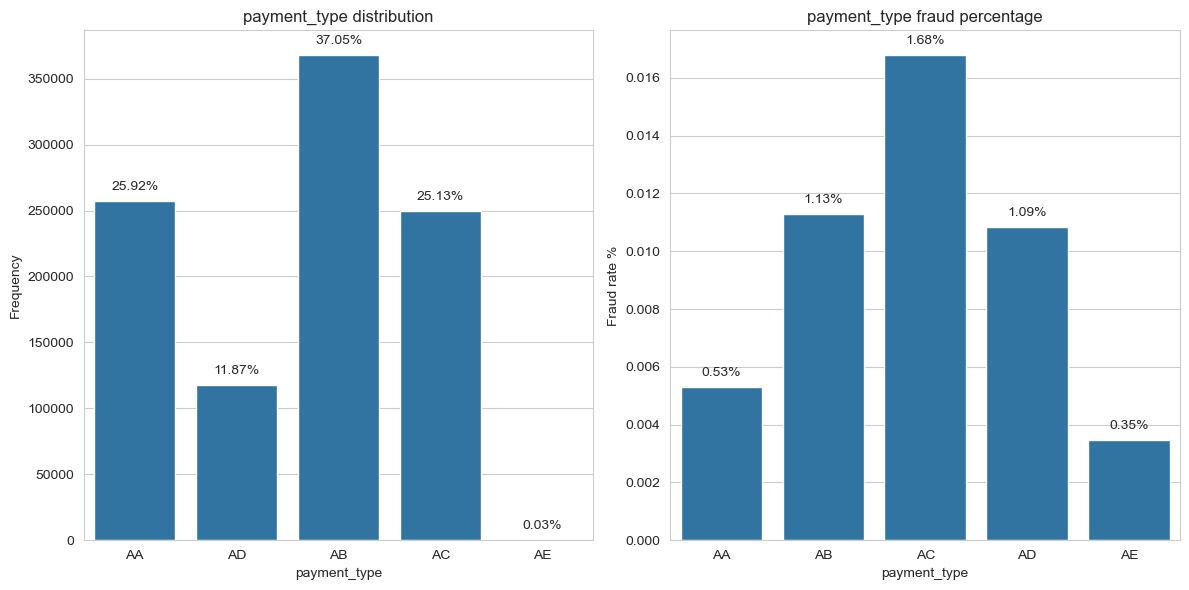

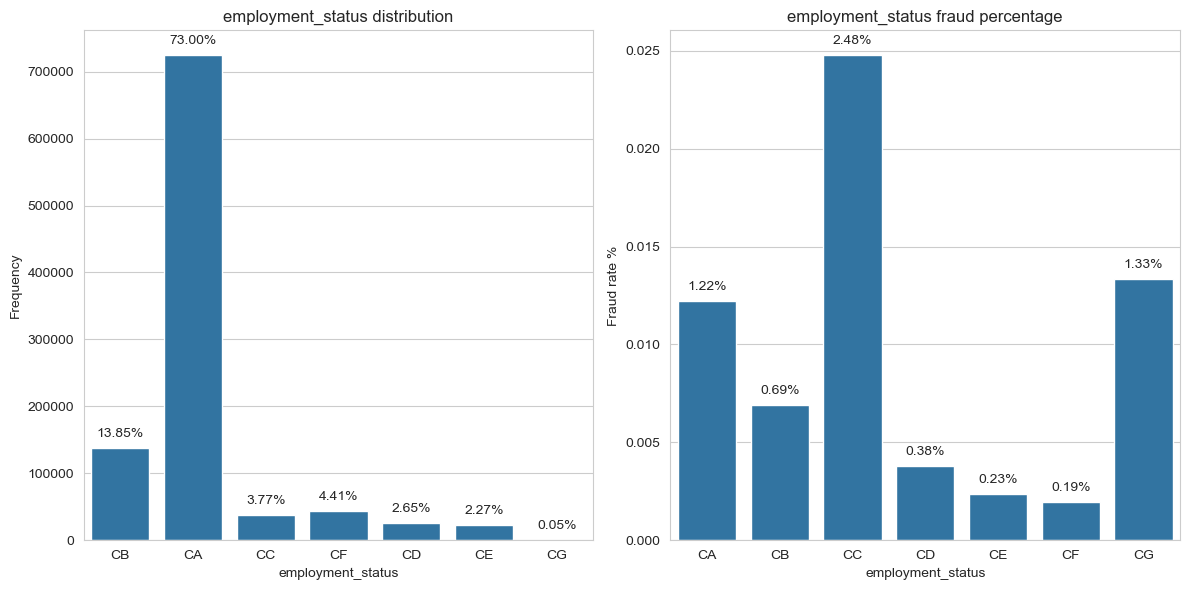

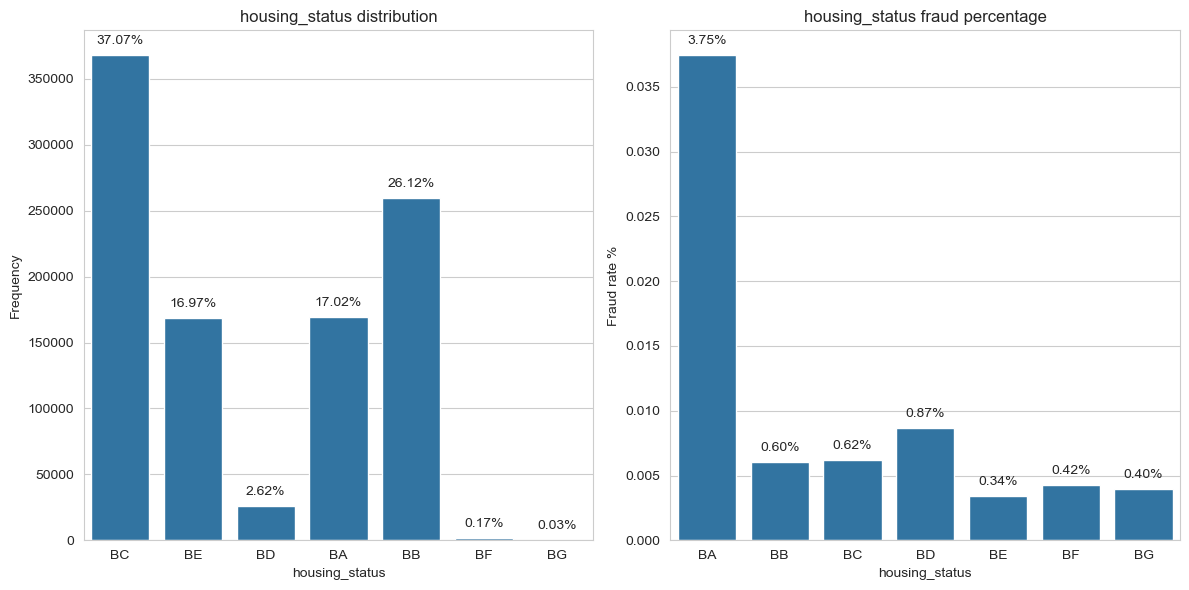

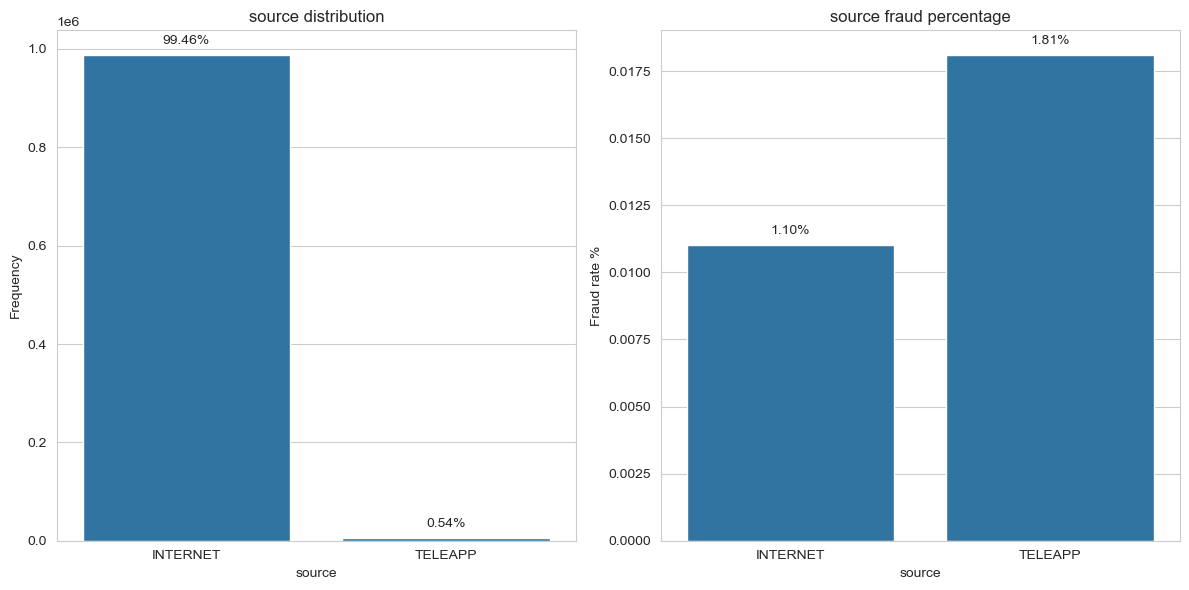

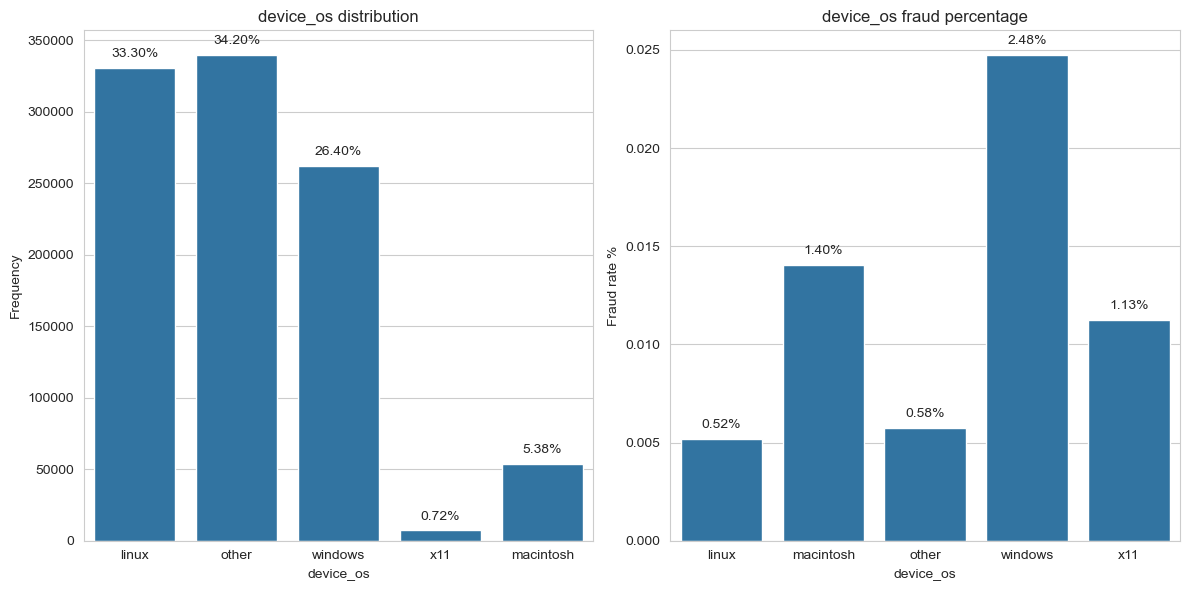

In [28]:
# Check categorical features distributions

def visualize_categorical_feature(data, *features):
    for feature in features:
        plt.figure(figsize=(12, 6))

        # Left: show how many times (%) each category appears in the dataset.
        plt.subplot(1, 2, 1)
        ax1 = sns.countplot(data=data, x=feature)
        total = len(data)
        for p in ax1.patches:
            height = p.get_height()
            ax1.annotate(f'{height/total:.2%}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', xytext=(0, 10), textcoords='offset points')
        plt.title(f'{feature} distribution')
        plt.ylabel('Frequency')
        
        # Right: Groups the data by the categorical feature and calculates the average fraud rate (%) for each group.
        plt.subplot(1, 2, 2)
        fraud_data = data.groupby(feature)['fraud_bool'].mean().reset_index()
        ax2 = sns.barplot(data=fraud_data, x=feature, y='fraud_bool')
        for p in ax2.patches:
            height = p.get_height()
            ax2.annotate(f'{height:.2%}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', xytext=(0, 10), textcoords='offset points')
        plt.title(f'{feature} fraud percentage')
        plt.ylabel('Fraud rate %')
        
        plt.tight_layout()
        plt.show()

# apply the function to categorical variables
visualize_categorical_feature(df, 'payment_type', 'employment_status', 'housing_status', 'source', 'device_os')

<li> Demographical Features Check

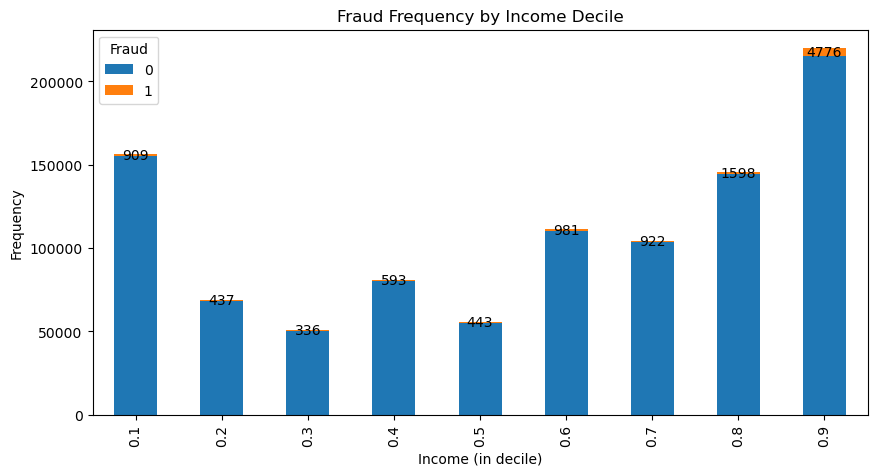

In [20]:
# Fraud vs. non-Fraud # by incomes

df['income'] = df['income'].astype(float).round(1).astype(str)
df['fraud_bool'] = df['fraud_bool'].astype(int)

grouped = df.groupby(['income', 'fraud_bool']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 5))
grouped.plot(kind='bar', stacked=True, ax=ax)

ax.set_title('Fraud Frequency by Income Decile')
ax.set_xlabel('Income (in decile)')
ax.set_ylabel('Frequency')
ax.legend(title='Fraud', loc='upper left')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()

    if p.get_facecolor() == ax.get_legend().get_patches()[1].get_facecolor():
        if height > 0:  
            ax.text(x + width/2, y + height/2, int(height), ha='center', va='center', fontsize=10, color='black')

plt.show()

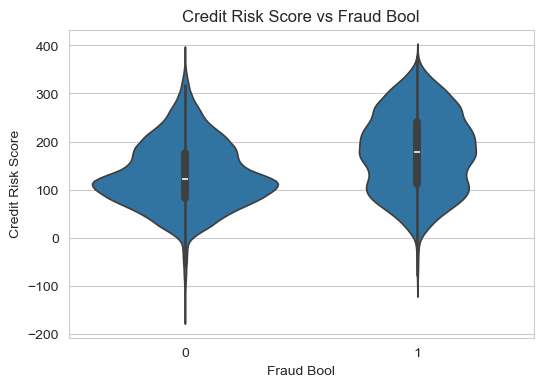

In [103]:
# Credit score across Fraud vs. non-Fraud
plt.figure(figsize=(6, 4))
sns.violinplot(x='fraud_bool', y='credit_risk_score', data=df)
plt.title('Credit Risk Score vs Fraud Bool')
plt.xlabel('Fraud Bool')
plt.ylabel('Credit Risk Score')
plt.show()

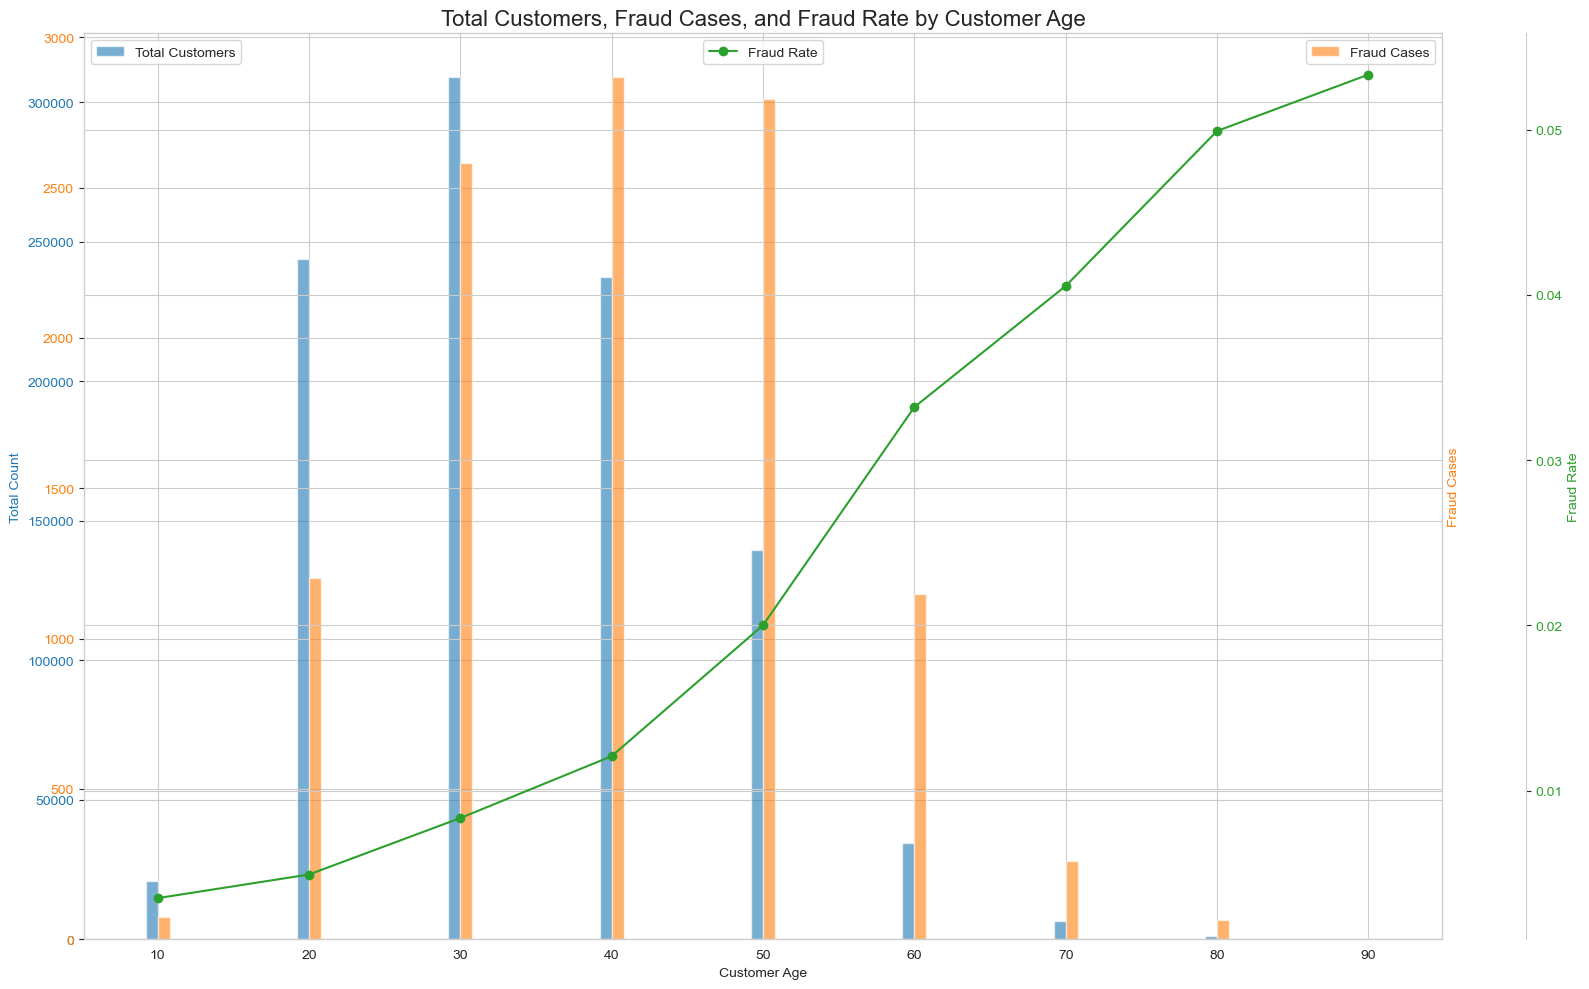

In [32]:
# Number of total customers, # of fraud cases, fraud rate by ages

# Count total customer number and fraud cases number by age
age_counts = df['customer_age'].value_counts().sort_index()
fraud_counts = df[df['fraud_bool'] == 1]['customer_age'].value_counts().sort_index()
fraud_counts = fraud_counts.reindex(age_counts.index, fill_value=0)

# Calculate fraud rate
fraud_rate = fraud_counts / age_counts

# Plot
fig, ax1 = plt.subplots(figsize=(16, 10))
bar_width = 0.8

ax1.bar(age_counts.index - bar_width/2, age_counts.values, bar_width, color='#1f77b4', alpha=0.6, label='Total Customers')
ax1.set_xlabel('Customer Age')
ax1.set_ylabel('Total Count', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

ax2 = ax1.twinx()
ax2.bar(fraud_counts.index + bar_width/2, fraud_counts.values, bar_width, color='#ff7f0e', alpha=0.6, label='Fraud Cases')
ax2.set_ylabel('Fraud Cases', color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

ax3 = ax2.twinx()
ax3.plot(age_counts.index, fraud_rate.values, color='#2ca02c', marker='o', linestyle='-', label='Fraud Rate')
ax3.set_ylabel('Fraud Rate', color='#2ca02c')
ax3.tick_params(axis='y', labelcolor='#2ca02c')
ax3.spines['right'].set_position(('outward', 60))

plt.title('Total Customers, Fraud Cases, and Fraud Rate by Customer Age', fontsize=16)
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax3.legend(loc='upper center')

plt.show()

In [ ]:
'''
Plot:
    - Blue bars (left axis): total number of customers per age group
    - Orange bars (right axis): number of fraud cases per age group
    - Green line (rightmost axis): fraud rate (% of customers who are frauds) per age group
Interpretations:
    Total Customers (Blue Bars):
        - Most customers are concentrated in the 20–40 age range.
        - The peak is at age 30, followed by age 20 and 40.
    Fraud Cases (Orange Bars):
        - The number of fraud cases follows a similar pattern to total customers.
        - Some older groups (50–70) have relatively high fraud cases despite lower customer counts.
    Fraud Rate (Green Line):
        - Fraud rate increases with age.
        - Customers aged 50 and above have noticeably higher fraud rates, despite being a smaller group.
        - The highest fraud rate is around age 80–90.
'''

<h2>Feature Engineering</h2>
<li>Test for Multicollinearity

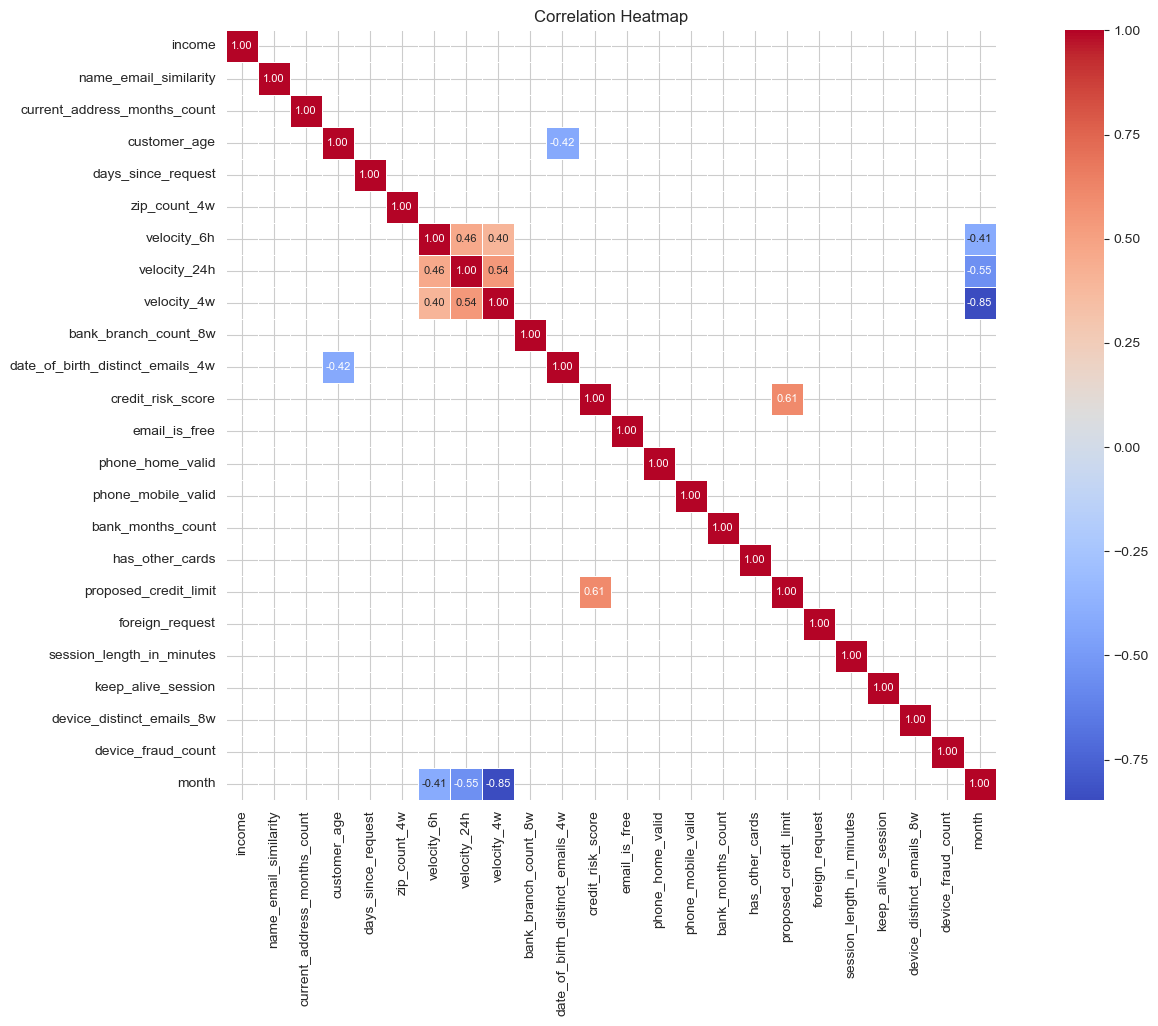

In [66]:
# Generate correlation heatmap

X = df.drop(columns='fraud_bool')  # Create a feature matrix X by removing the target variable (fraud_bool) from the dataset
numeric_features = [col for col in X.select_dtypes(include='number').columns]

# Scale the numeric features to a 0–1 range using MinMaxScaler
X_scaled = MinMaxScaler().fit_transform(X[numeric_features])
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_features)  # Convert the scaled NumPy array back into a pandas DataFrame

# Calculate the pairwise Pearson correlation coefficient for all numeric columns
correlation_matrix = X_scaled_df.corr()

# Filter correlations
filtered_corr = correlation_matrix[(correlation_matrix >= 0.4) | (correlation_matrix <= -0.4)].copy()

# Always include the diagonal (self-correlation = 1.0)
np.fill_diagonal(filtered_corr.values, 1.0)

# Plot correlation matrix with annotated values
fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(filtered_corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, square=True, ax=ax, annot_kws={"fontsize": 8})
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
'''
Highly Correlated Pairs (multicollinearity):
These features are behavior-based metrics over different time windows, so correlation is expected.
    velocity_6h & velocity_24h: 0.46
    velocity_6h & velocity_4w: 0.40
    velocity_24h & velocity_4w: 0.54
Othe notable correaltions:
    proposed_credit_limit & credit_risk_score: 0.61 (riskier profiles tend to ask for higher limits)
'''

<h2>Basic Models</h2>
<li>Logistic Regression

In [19]:
# Split dataset: train (80%), test (20%)

# Define features and target
X = df.drop(columns='fraud_bool')
y = df['fraud_bool']  # target column (y)

# Split dataset
x_train, x_test, y_train, y_test = train_test_split(
    X, y,                   # Input features and target
    test_size=0.2,          # 20% of data goes to test set
    random_state=42,        # For reproducibility
    shuffle=True            # Randomly shuffle before splitting
)

# Define preprocessing

# For numerical features, scales each number to a range between 0 and 1.
numeric_transformer = MinMaxScaler()

# For categorical features, turns categories into binary columns.
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include='number')),
        ('cat', categorical_transformer, make_column_selector(dtype_include='object'))
    ]
)

In [86]:
# Transform and convert to DataFrame
x_train_scaled = preprocessor.fit_transform(x_train)
x_test_scaled = preprocessor.transform(x_test)

# Get feature names after transformation
new_columns = preprocessor.get_feature_names_out()

# Convert to DataFrames
x_train_scaled = pd.DataFrame(x_train_scaled, columns=new_columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=new_columns)

In [88]:
# Train logistic regression model with train data
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(x_train_scaled, y_train)

# Predict with test data
y_pred_proba = lr_model.predict_proba(x_test_scaled)[:, 1]
y_pred_label = lr_model.predict(x_test_scaled)

# Evaluation
print("AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("Classification Report:")
print(classification_report(y_test, y_pred_label, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_label))

AUC Score: 0.8711383493577066
Classification Report:
              precision    recall  f1-score   support

           0     0.9969    0.8045    0.8904    196530
           1     0.0424    0.7755    0.0803      2192

    accuracy                         0.8041    198722
   macro avg     0.5196    0.7900    0.4854    198722
weighted avg     0.9864    0.8041    0.8815    198722

Confusion Matrix:
[[158100  38430]
 [   492   1700]]


<li> Minimize FPR at a fixed TPR = 0.8

In [80]:
def find_fpr_for_recall_target(y_true, y_proba, recall_target=0.80):
    """
    Finds the lowest FPR of the model while while catching 80% of all frauds (TPR=0.8)
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    valid = tpr >= recall_target  # Filter for TPR ≥ recall target

    if not any(valid):
        print("No threshold achieves the required recall.")
        return None

    idx = np.argmin(fpr[valid])  # Among FPR with >= 0.8 TPR, find the min FPR
    threshold = thresholds[valid][idx]
    best_fpr = fpr[valid][idx]
    best_tpr = tpr[valid][idx]

    print(f"Lowest FPR:{best_fpr:.4f}")
    print(f"Threshold: {threshold:.4f}")
    print(f"TPR: {best_tpr:.4f}")

    return threshold, best_fpr, best_tpr

In [90]:
# Apply the function above to the logistic regression result
threshold, fpr, tpr = find_fpr_for_recall_target(y_test, y_pred_proba, recall_target=0.80)

Lowest FPR:0.2166
Threshold: 0.4692
TPR: 0.8002


In [ ]:
'''
The new TPR 0.80 is higher than original TPR = 1700 / (1700+492) = 0.7755.
The new FPR 0.2166 increased a bit than the original FPR = 38430 / (158100+38430) = 0.195, but it's still optimal given the TPR constraint.
'''

<li> Quadratic discriminant analysis (QDA) Model

In [ ]:
'''
QDA assumes each class has its own covariance matrix, may overfit with this imbalanced dataset.
Some features are highly correlated.
'''

In [35]:
# Train QDA model with train data
qda_model = QuadraticDiscriminantAnalysis()
qda_model.fit(x_train_scaled, y_train)

# Predict probabilities with test data
y_pred_proba_qda = qda_model.predict_proba(x_test_scaled)[:, 1]
y_pred_label_qda = qda_model.predict(x_test_scaled)

# Evaluation
print("AUC Score (QDA):", roc_auc_score(y_test, y_pred_proba_qda))
print("Classification Report (QDA):")
print(classification_report(y_test, y_pred_label_qda, digits=4))
print("Confusion Matrix (QDA):")
print(confusion_matrix(y_test, y_pred_label_qda))

C:\Users\Mingw\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


AUC Score (QDA): 0.6303667177073317
Classification Report (QDA):
              precision    recall  f1-score   support

           0     0.9954    0.1633    0.2806    196530
           1     0.0123    0.9320    0.0242      2192

    accuracy                         0.1718    198722
   macro avg     0.5038    0.5477    0.1524    198722
weighted avg     0.9845    0.1718    0.2777    198722

Confusion Matrix (QDA):
[[ 32094 164436]
 [   149   2043]]


<h2>Modeling Preparation</h2>
<li>Reduce Class Imbalance before split data

In [94]:
# Use undersampling techniques to handle class imbalance

from imblearn.under_sampling import NearMiss

def undersample_majority_class(x, y, ratio=10):
    minority_class_size = np.sum(y == 1)  # Counts how many fraud (class = 1) samples exist.
    majority_class_size = minority_class_size * ratio  # Compute how many majority (non-fraud) samples to keep according to the raito

    undersample = NearMiss(sampling_strategy=1/ratio, n_jobs=-1)  # Use NearMiss strategy
    x_resampled, y_resampled = undersample.fit_resample(x, y)

    return x_resampled, y_resampled

In [96]:
# Encode categorical features (since NearMiss undersampling only works with numeric data)
X_encoded = X.copy()
cat_cols = X_encoded.select_dtypes(include='object').columns
encoder = OrdinalEncoder()
X_encoded[cat_cols] = encoder.fit_transform(X_encoded[cat_cols])

# target variable (y)
y = df['fraud_bool']

# Apply NearMiss undersampling
X_nm, y_nm = undersample_majority_class(X_encoded, y, ratio=10)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(X_nm, y_nm, test_size=0.2, random_state=42, shuffle=True)

# Check class balance
print(Counter(y_train), Counter(y_test))

Counter({0: 87895, 1: 8861}) Counter({0: 22055, 1: 2134})


In [98]:
# Prepocessing data

# Identify numerical features (e.x.: age, income): with >= 10 unique values
numeric_features_name=[x for x in df.columns if df[x].nunique() >= 10]
numeric_features = df[numeric_features_name]

numeric_transformer = StandardScaler()  # Standardize numerical features

# Column transformer
preprocessor = ColumnTransformer([('scaled', numeric_transformer, numeric_features_name)], remainder='passthrough')
x_train_scaled = preprocessor.fit_transform(x_train)
x_test_scaled = preprocessor.transform(x_test)

# Transform to DataFrames
new_columns = numeric_features_name + [col for col in x_train.columns if col not in numeric_features_name]
x_train_scaled = pd.DataFrame(x_train_scaled, columns=new_columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=new_columns)

# Identify categorical features: with 2 <= x < 10 unique values
categorical_features_name = [col for col in x_train_scaled.columns if 2 <= x_train_scaled[col].nunique() < 10]
all_features = list(x_train_scaled.columns) 
categorical_feature_indices = [i for i, feature in enumerate(all_features) if feature in categorical_features_name]

<h2>Machine Learning Models</h2>
<li>Decision Tree

In [102]:
# Train the model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train_scaled, y_train)

# Predict
y_pred_dt = dt_model.predict(x_test_scaled)
y_proba_dt = dt_model.predict_proba(x_test_scaled)[:, 1]

# Evaluate
print("AUC Score (Decision Tree):", roc_auc_score(y_test, y_proba_dt))
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix (Decision Tree):")
print(confusion_matrix(y_test, y_pred_dt))

AUC Score (Decision Tree): 0.7589902937127658
Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     22055
           1       0.55      0.56      0.56      2134

    accuracy                           0.92     24189
   macro avg       0.75      0.76      0.76     24189
weighted avg       0.92      0.92      0.92     24189

Confusion Matrix (Decision Tree):
[[21077   978]
 [  934  1200]]


In [ ]:
'''
Decision Tree Evaluation:
    - AUC is relatively higher than QDA, but lower than Logistic Reg.
    - Recall = 0.56: catch 56% of real fraud.
    - Precision = 0.55: about half of the predicted frauds are correct.
'''

                         feature  importance
3                   zip_count_4w    0.147943
5                   velocity_24h    0.109547
18                housing_status    0.099563
7           bank_branch_count_8w    0.083262
11         proposed_credit_limit    0.070048
4                    velocity_6h    0.066315
6                    velocity_4w    0.062855
0          name_email_similarity    0.042774
9              credit_risk_score    0.040578
1   current_address_months_count    0.040013


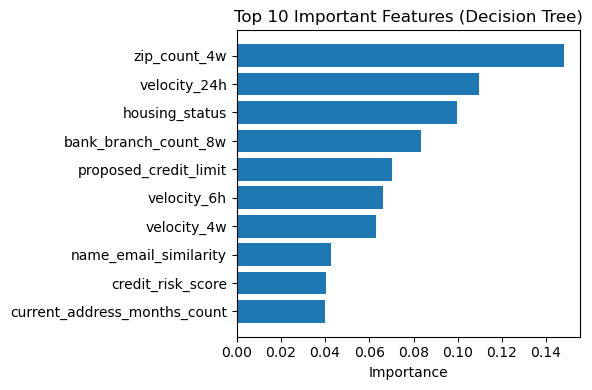

In [106]:
# Feature Importance

# built-in attribute 'dt_model.feature_importances_' to check feature importance
feature_importance = pd.DataFrame({
    'feature': x_train_scaled.columns,
    'importance': dt_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(by='importance', ascending=False)

# Display top features
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(6,4))
plt.barh(feature_importance['feature'][:10][::-1], feature_importance['importance'][:10][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Important Features (Decision Tree)")
plt.tight_layout()
plt.show()

<li>Random Forest

In [112]:
# Train the model
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(x_train_scaled, y_train)

# Predict
y_pred_rf = rf_model.predict(x_test_scaled)
y_proba_rf = rf_model.predict_proba(x_test_scaled)[:, 1]

# Evaluate
print("AUC Score (RF):", roc_auc_score(y_test, y_proba_rf))
print("Classification Report (RF):")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix (RF):")
print(confusion_matrix(y_test, y_pred_rf))

AUC Score (RF): 0.9444792742519607
Classification Report (RF):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     22055
           1       0.88      0.52      0.65      2134

    accuracy                           0.95     24189
   macro avg       0.92      0.76      0.81     24189
weighted avg       0.95      0.95      0.95     24189

Confusion Matrix (RF):
[[21910   145]
 [ 1025  1109]]


In [ ]:
'''
Random Forest Evaluation:
    - AUC = 0.94 is really high, indicating the model separates fraud vs. non-fraud well.
    - Recall = 0.52: catch 52% of real fraud.
    - Precision = 0.88: most predicted frauds are correct.
'''

                         feature  importance
3                   zip_count_4w    0.118592
5                   velocity_24h    0.090759
7           bank_branch_count_8w    0.083343
6                    velocity_4w    0.072724
4                    velocity_6h    0.065809
18                housing_status    0.065454
11         proposed_credit_limit    0.062192
9              credit_risk_score    0.061175
0          name_email_similarity    0.045823
1   current_address_months_count    0.044467


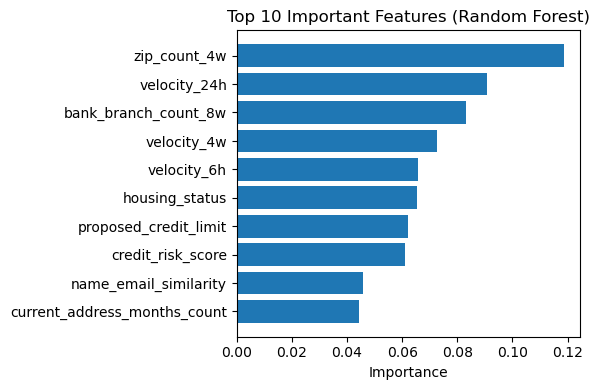

In [114]:
# Feature Importance

# built-in attribute 'dt_model.feature_importances_' to check feature importance
feature_importance = pd.DataFrame({
    'feature': x_train_scaled.columns,
    'importance': rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(by='importance', ascending=False)

# Display top features
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(6,4))
plt.barh(feature_importance['feature'][:10][::-1], feature_importance['importance'][:10][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Important Features (Random Forest)")
plt.tight_layout()
plt.show()

<li>XGBoost

In [127]:
# Train the model
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_model.fit(x_train_scaled, y_train)

# Predict
y_pred_xgb = xgb_model.predict(x_test_scaled)
y_proba_xgb = xgb_model.predict_proba(x_test_scaled)[:, 1]

# Evaluation
print("AUC Score (XGBoost):", roc_auc_score(y_test, y_proba_xgb))
print("Classification Report (XGB):")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix (XGB):")
print(confusion_matrix(y_test, y_pred_xgb))

AUC Score (XGBoost): 0.9577996093518439
Classification Report (XGB):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     22055
           1       0.86      0.64      0.73      2134

    accuracy                           0.96     24189
   macro avg       0.91      0.82      0.86     24189
weighted avg       0.96      0.96      0.96     24189

Confusion Matrix (XGB):
[[21826   229]
 [  763  1371]]


In [ ]:
'''
XGBoost Evaluation: 
* Performs better overall than Decision Tree and Random Forest
    - AUC = 0.958 is the highest (even better than Decision Tree and RF), indicating the model separates fraud vs. non-fraud well.
    - Recall = 0.64: catch 64% of real fraud (increased from Decision Tree and RF).
    - Precision = 0.86: most predicted frauds are correct.
    - Macro avg F1 = 0.91: improved overall balance across classes.
'''

<Figure size 600x400 with 0 Axes>

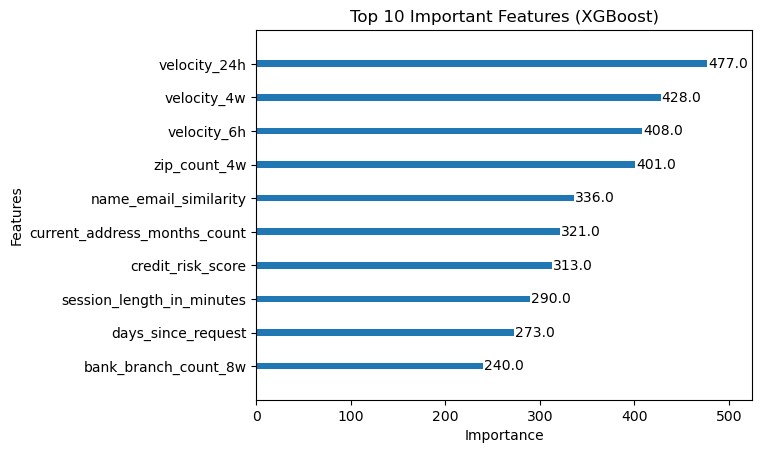

In [135]:
# Feature Importance

# XGBoost built-in plot package for feature importance
from xgboost import plot_importance

plt.figure(figsize=(6, 4))
plot_importance(xgb_model, max_num_features=10, importance_type='weight')
plt.title("Top 10 Important Features (XGBoost)")
plt.xlabel("Importance")
plt.grid(False)
plt.show()

<h2>Try with a completely balanced data</h2>
<li>Same procedure as above

In [23]:
from imblearn.under_sampling import NearMiss

def undersample_majority_class(x, y):
    minority_class_size = np.sum(y == 1)  # Counts how many fraud (class = 1) samples exist.
    majority_class_size = minority_class_size  # Compute how many majority (non-fraud) samples to keep according to the raito

    undersample = NearMiss(sampling_strategy=1.0, n_jobs=-1)  # Use NearMiss strategy
    x_resampled, y_resampled = undersample.fit_resample(x, y)

    return x_resampled, y_resampled

# Encode categorical features (since NearMiss undersampling only works with numeric data)
X_encoded = X.copy()
cat_cols = X_encoded.select_dtypes(include='object').columns
encoder = OrdinalEncoder()
X_encoded[cat_cols] = encoder.fit_transform(X_encoded[cat_cols])

# target variable (y)
y = df['fraud_bool']

# Apply NearMiss undersampling
X_nm, y_nm = undersample_majority_class(X_encoded, y)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(X_nm, y_nm, test_size=0.2, random_state=42, shuffle=True)

# Check class balance
print(Counter(y_train), Counter(y_test))

Counter({1: 73, 0: 72}) Counter({0: 19, 1: 18})


In [25]:
# Prepocessing data

# Identify numerical features (e.x.: age, income): with >= 10 unique values
numeric_features_name=[x for x in df.columns if df[x].nunique() >= 10]
numeric_features = df[numeric_features_name]

numeric_transformer = StandardScaler()  # Standardize numerical features

# Column transformer
preprocessor = ColumnTransformer([('scaled', numeric_transformer, numeric_features_name)], remainder='passthrough')
x_train_scaled = preprocessor.fit_transform(x_train)
x_test_scaled = preprocessor.transform(x_test)

# Transform to DataFrames
new_columns = numeric_features_name + [col for col in x_train.columns if col not in numeric_features_name]
x_train_scaled = pd.DataFrame(x_train_scaled, columns=new_columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=new_columns)

# Identify categorical features: with 2 <= x < 10 unique values
categorical_features_name = [col for col in x_train_scaled.columns if 2 <= x_train_scaled[col].nunique() < 10]
all_features = list(x_train_scaled.columns) 
categorical_feature_indices = [i for i, feature in enumerate(all_features) if feature in categorical_features_name]

In [37]:
# Define models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
}

# Train and evaluate
for name, model in models.items():
    print()
    print(f"{name}")
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1]

    print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print()
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    print()
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Decision Tree
AUC: 0.7880

Classification Report:
              precision    recall  f1-score   support

           0     0.9231    0.6316    0.7500        19
           1     0.7083    0.9444    0.8095        18

    accuracy                         0.7838        37
   macro avg     0.8157    0.7880    0.7798        37
weighted avg     0.8186    0.7838    0.7790        37


Confusion Matrix:
[[12  7]
 [ 1 17]]

Random Forest
AUC: 0.9722

Classification Report:
              precision    recall  f1-score   support

           0     0.9375    0.7895    0.8571        19
           1     0.8095    0.9444    0.8718        18

    accuracy                         0.8649        37
   macro avg     0.8735    0.8670    0.8645        37
weighted avg     0.8752    0.8649    0.8643        37


Confusion Matrix:
[[15  4]
 [ 1 17]]

XGBoost
AUC: 0.9620

Classification Report:
              precision    recall  f1-score   support

           0     0.8947    0.8947    0.8947        19
           1  

In [ ]:
'''
Model Performance (Ratio=10) vs. (Ratio 1:1)
Model         | AUC (Ratio=10) | Recall (Fraud) | Precision (Fraud) | AUC (1:1) | Recall (Fraud) | Precision (Fraud)
Decision Tree | 0.7590         | 0.56           | 0.55              | 0.7880    | 0.9444         | 0.7083
Random Forest | 0.9445         | 0.52           | 0.88              | 0.9722    | 0.9444         | 0.8095
XGBoost       | 0.9580         | 0.64           | 0.86              | 0.9620    | 0.8889         | 0.8889

* In all 3 models, recall jumped from 50–60% (Ratio=10) to 89–94% (1:1).
Balancing with 1:1 allowed the models to better learn the minority class (fraud) and reduce false negatives.

* Precision dropped a bit after full balancing.
Trade-off: higher recall → more false positives.

* Ratio=10 still left the dataset highly imbalanced, leading to models biased toward predicting “Not Fraud.”
Full balancing (1:1) allowed models to:
    - Better learn the fraud signal
    - Optimize thresholds more fairly
    - Boost sensitivity (recall)
'''